Cantidad de puntos cercanos: 78
Punto más cercano: (4980, 4931) Distancia: 71.84010022264724


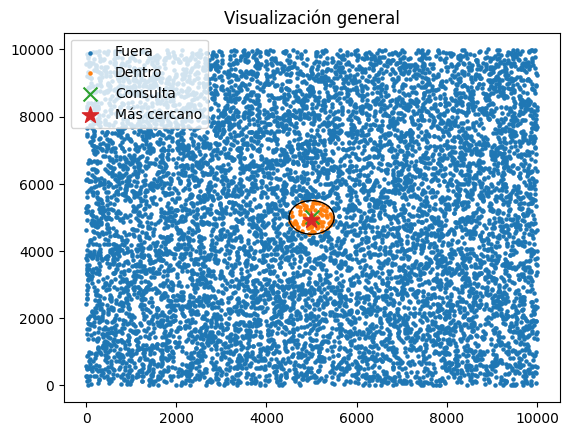

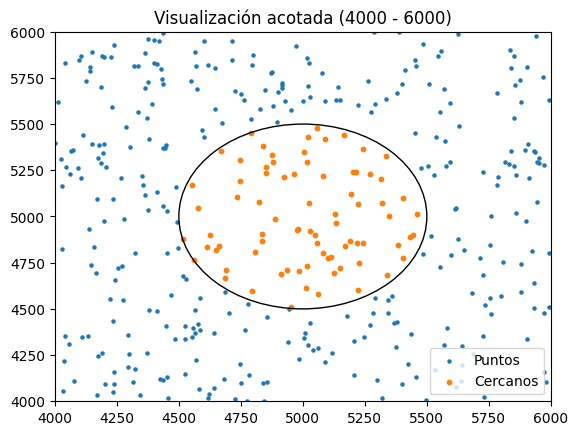


Tamaño: 5
Fuerza bruta: 0.00000488
KD-Tree:      0.00000265
➡️ Gana KD-Tree

Tamaño: 50
Fuerza bruta: 0.00005342
KD-Tree:      0.00000679
➡️ Gana KD-Tree

Tamaño: 100
Fuerza bruta: 0.00008795
KD-Tree:      0.00002548
➡️ Gana KD-Tree

Tamaño: 300
Fuerza bruta: 0.00026333
KD-Tree:      0.00002852
➡️ Gana KD-Tree

Tamaño: 600
Fuerza bruta: 0.00053461
KD-Tree:      0.00004010
➡️ Gana KD-Tree

Tamaño: 1000
Fuerza bruta: 0.00096472
KD-Tree:      0.00006972
➡️ Gana KD-Tree

Tamaño: 2000
Fuerza bruta: 0.00208148
KD-Tree:      0.00009039
➡️ Gana KD-Tree

Tamaño: 5000
Fuerza bruta: 0.00500372
KD-Tree:      0.00014429
➡️ Gana KD-Tree

Tamaño: 10000
Fuerza bruta: 0.01627533
KD-Tree:      0.00033031
➡️ Gana KD-Tree


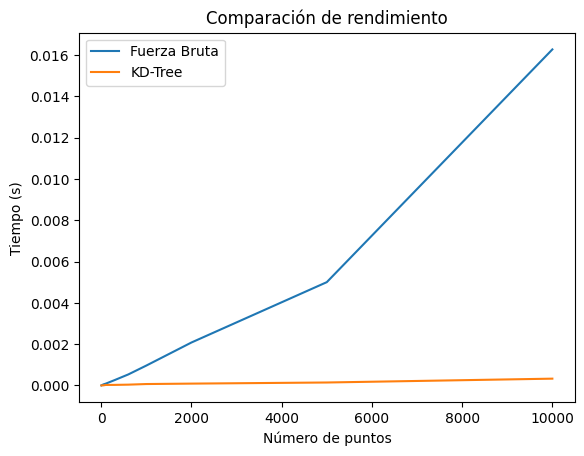

In [3]:
# =========================================
# IMPORTS
# =========================================
import random
import math
import matplotlib.pyplot as plt
import time
import statistics

# =========================================
# CELDA DE TEXTO: INTRODUCCIÓN
# =========================================
"""
Este programa compara dos métodos de búsqueda espacial:

1. Fuerza bruta
2. KD-Tree

Se analiza su rendimiento en diferentes tamaños de datos.
"""

# =========================================
# CONFIGURACIÓN
# =========================================
k = 2
consulta = (5000, 5000)
radio = 500

num_puntos = 10000
puntos = [tuple(random.randint(0, 10000) for _ in range(k)) for _ in range(num_puntos)]

# =========================================
# DISTANCIA
# =========================================
def distancia(a, b):
    return math.sqrt(sum((a[i] - b[i])**2 for i in range(len(a))))

# =========================================
# FUERZA BRUTA
# =========================================
puntos_cercanos = [p for p in puntos if distancia(p, consulta) <= radio]

min_dist = float("inf")
mas_cercano = None

for p in puntos:
    d = distancia(p, consulta)
    if d < min_dist:
        min_dist = d
        mas_cercano = p

print("Cantidad de puntos cercanos:", len(puntos_cercanos))
print("Punto más cercano:", mas_cercano, "Distancia:", min_dist)

# =========================================
# VISUALIZACIÓN GENERAL
# =========================================
if k == 2:
    plt.figure()

    puntos_fuera = [p for p in puntos if distancia(p, consulta) > radio]

    plt.scatter([p[0] for p in puntos_fuera], [p[1] for p in puntos_fuera], s=5, label="Fuera")
    plt.scatter([p[0] for p in puntos_cercanos], [p[1] for p in puntos_cercanos], s=5, label="Dentro")

    plt.scatter(consulta[0], consulta[1], marker='x', s=100, label="Consulta")
    plt.scatter(mas_cercano[0], mas_cercano[1], marker='*', s=150, label="Más cercano")

    circulo = plt.Circle(consulta, radio, fill=False)
    plt.gca().add_patch(circulo)

    plt.legend()
    plt.title("Visualización general")
    plt.show()

# =========================================
# VISUALIZACIÓN ACOTADA
# =========================================
if k == 2:
    plt.figure()

    puntos_rango = [p for p in puntos if 4000 <= p[0] <= 6000 and 4000 <= p[1] <= 6000]
    puntos_cercanos_rango = [p for p in puntos_cercanos if 4000 <= p[0] <= 6000 and 4000 <= p[1] <= 6000]

    plt.scatter([p[0] for p in puntos_rango], [p[1] for p in puntos_rango], s=5, label="Puntos")
    plt.scatter([p[0] for p in puntos_cercanos_rango], [p[1] for p in puntos_cercanos_rango], s=10, label="Cercanos")

    circulo = plt.Circle(consulta, radio, fill=False, linestyle='-')
    plt.gca().add_patch(circulo)

    plt.xlim(4000, 6000)
    plt.ylim(4000, 6000)

    plt.title("Visualización acotada (4000 - 6000)")
    plt.legend()
    plt.show()

# =========================================
# KD-TREE
# =========================================
class Nodo:
    def __init__(self, punto, eje, izquierda=None, derecha=None):
        self.punto = punto
        self.eje = eje
        self.izquierda = izquierda
        self.derecha = derecha

def construir_kdtree(puntos, profundidad=0):
    if not puntos:
        return None

    eje = profundidad % 2
    valores = [p[eje] for p in puntos]

    mediana = statistics.median(valores)

    punto_mediana = min(puntos, key=lambda p: abs(p[eje] - mediana))

    izquierda = [p for p in puntos if p[eje] < punto_mediana[eje]]
    derecha = [p for p in puntos if p[eje] > punto_mediana[eje]]

    return Nodo(
        punto=punto_mediana,
        eje=eje,
        izquierda=construir_kdtree(izquierda, profundidad + 1),
        derecha=construir_kdtree(derecha, profundidad + 1)
    )

def buscar_en_rango(nodo, punto_consulta, radio, encontrados):
    if nodo is None:
        return

    if distancia(nodo.punto, punto_consulta) <= radio:
        encontrados.append(nodo.punto)

    eje = nodo.eje

    if punto_consulta[eje] - radio <= nodo.punto[eje]:
        buscar_en_rango(nodo.izquierda, punto_consulta, radio, encontrados)

    if punto_consulta[eje] + radio >= nodo.punto[eje]:
        buscar_en_rango(nodo.derecha, punto_consulta, radio, encontrados)

# Construcción del árbol
arbol = construir_kdtree(puntos)

# =========================================
# ANÁLISIS DE RENDIMIENTO MULTI-TAMAÑO
# =========================================
tamaños = [5, 50, 100, 300, 600, 1000, 2000, 5000, 10000]

resultados_fb = []
resultados_kd = []

for n in tamaños:

    puntos_temp = [tuple(random.randint(0, 10000) for _ in range(k)) for _ in range(n)]
    arbol_temp = construir_kdtree(puntos_temp)

    pruebas = 100

    tiempo_fb = 0
    tiempo_kd = 0

    for _ in range(pruebas):

        # Fuerza bruta
        inicio = time.perf_counter()
        [p for p in puntos_temp if distancia(p, consulta) <= radio]
        tiempo_fb += time.perf_counter() - inicio

        # KD-Tree
        inicio = time.perf_counter()
        encontrados = []
        buscar_en_rango(arbol_temp, consulta, radio, encontrados)
        tiempo_kd += time.perf_counter() - inicio

    tiempo_fb /= pruebas
    tiempo_kd /= pruebas

    resultados_fb.append(tiempo_fb)
    resultados_kd.append(tiempo_kd)

    print(f"\nTamaño: {n}")
    print(f"Fuerza bruta: {tiempo_fb:.8f}")
    print(f"KD-Tree:      {tiempo_kd:.8f}")

    if tiempo_fb < tiempo_kd:
        print("➡️ Gana Fuerza Bruta")
    else:
        print("➡️ Gana KD-Tree")

# =========================================
# DISCUSIÓN DE RESULTADOS
# =========================================
"""
=========================================
CELDA DE TEXTO 7: DISCUSIÓN DE RESULTADOS
=========================================
Observaciones esperadas:

1. Para tamaños pequeños:
   - Fuerza bruta suele ser más rápida
   - Esto se debe a que el KD-Tree tiene overhead

2. Para tamaños grandes:
   - KD-Tree se vuelve más eficiente
   - Reduce el número de comparaciones

3. Punto de cambio:
   - Generalmente entre 500 y 2000 puntos
   - Depende de la distribución de datos

Conclusión:
El KD-Tree es más escalable, mientras que
la fuerza bruta es más simple y eficiente en casos pequeños.
"""

# =========================================
# GRÁFICA FINAL
# =========================================
plt.figure()

plt.plot(tamaños, resultados_fb, label="Fuerza Bruta")
plt.plot(tamaños, resultados_kd, label="KD-Tree")

plt.xlabel("Número de puntos")
plt.ylabel("Tiempo (s)")
plt.title("Comparación de rendimiento")

plt.legend()
plt.show()